# 07 — LightGBM

RF より汎化に強いとされる勾配ブースティングを試す。

| 実験 | 内容 |
|------|------|
| 1 | RF ベースライン（snv+sg1）との比較 |
| 2 | LGBM ハイパラ3パターン比較 |
| 3 | 最良ハイパラ × 前処理比較（snv+sg1 / raw / sg2 / snv+sg2） |
| 4 | RF + LGBM アンサンブル |

> **CV**: GroupKFold(species_number, n_splits=5) — 訓練・テストの樹種分離を模倣

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline

from src.data_io import load_signate
from src.preprocessing import build_preprocessor
from src.feature_selection import NoSelection
from src.evaluation import compare_pipelines, plot_predictions, print_summary_table
from src.utils import make_submission, setup_japanese_font

plt.rcParams['figure.dpi'] = 110
setup_japanese_font()

ds_train = load_signate('train')
ds_test  = load_signate('test')
X, y, groups = ds_train.X, ds_train.y, ds_train.groups
X_test = ds_test.X

N_SPLITS = 5
print(f'train: {X.shape}  y: [{y.min():.1f}, {y.max():.1f}]')

train: (1322, 1555)  y: [0.8, 298.6]


## 1. RF ベースライン vs LGBM（ハイパラ3パターン）

前処理を snv+sg1（RF の現行ベスト）に固定して比較する。

| 設定 | 方針 |
|------|------|
| default | sklearn デフォルト相当。汎化前の確認。 |
| regularized | `num_leaves=15`, `min_child_samples=50`, `reg_lambda=5`。木を浅く・正則化強化で樹種間汎化を狙う。 |
| conservative | 学習率を下げて `n_estimators` を増やす。ゆっくり学習で過学習抑制。 |

In [2]:
LGBM_CONFIGS = {
    'LGBM-default': lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05,
        num_leaves=31, min_child_samples=20,
        subsample=0.8, colsample_bytree=0.3,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
    'LGBM-regularized': lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05,
        num_leaves=15, min_child_samples=50,
        subsample=0.8, colsample_bytree=0.3,
        reg_alpha=0.1, reg_lambda=5.0,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
    'LGBM-conservative': lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.02,
        num_leaves=15, min_child_samples=50,
        subsample=0.8, colsample_bytree=0.3,
        reg_alpha=0.1, reg_lambda=5.0,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
}

RF_BASELINE = RandomForestRegressor(
    n_estimators=300, max_features=0.3, random_state=42, n_jobs=-1
)

configs_1 = [
    {
        'name':         f'RF-baseline (snv+sg1)',
        'preprocessor': build_preprocessor('snv+sg1'),
        'selector':     NoSelection(),
        'model':        RF_BASELINE,
    }
] + [
    {
        'name':         f'{name} (snv+sg1)',
        'preprocessor': build_preprocessor('snv+sg1'),
        'selector':     NoSelection(),
        'model':        model,
    }
    for name, model in LGBM_CONFIGS.items()
]

df_1 = compare_pipelines(
    configs_1, X, y, groups, n_splits=N_SPLITS,
    save_dir='../results', filename='lgbm_step1_hyperparams.csv',
)
print_summary_table(df_1, '実験1: RF vs LGBM ハイパラ比較（snv+sg1）')

  [RF-baseline (snv+sg1)] RMSE=20.1910±11.3458  R²=0.818  RPD=2.45(fair)  TrainRMSE=1.9771
  [LGBM-default (snv+sg1)] 

c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

RMSE=20.2351±10.7114  R²=0.820  RPD=2.45(fair)  TrainRMSE=0.3410
  [LGBM-regularized (snv+sg1)] 

c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

RMSE=21.2294±10.8829  R²=0.807  RPD=2.33(fair)  TrainRMSE=1.4041
  [LGBM-conservative (snv+sg1)] 

c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

RMSE=20.8461±10.7600  R²=0.812  RPD=2.38(fair)  TrainRMSE=1.7790
  → Saved: ..\results\lgbm_step1_hyperparams.csv

  実験1: RF vs LGBM ハイパラ比較（snv+sg1）
                          name  CV_RMSE CV_RMSE_std  CV_R2   RPD Train_RMSE
0        RF-baseline (snv+sg1)  20.1910     11.3458  0.818  2.45     1.9771
1       LGBM-default (snv+sg1)  20.2351     10.7114  0.820  2.45     0.3410
2  LGBM-conservative (snv+sg1)  20.8461     10.7600  0.812  2.38     1.7790
3   LGBM-regularized (snv+sg1)  21.2294     10.8829  0.807  2.33     1.4041



c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


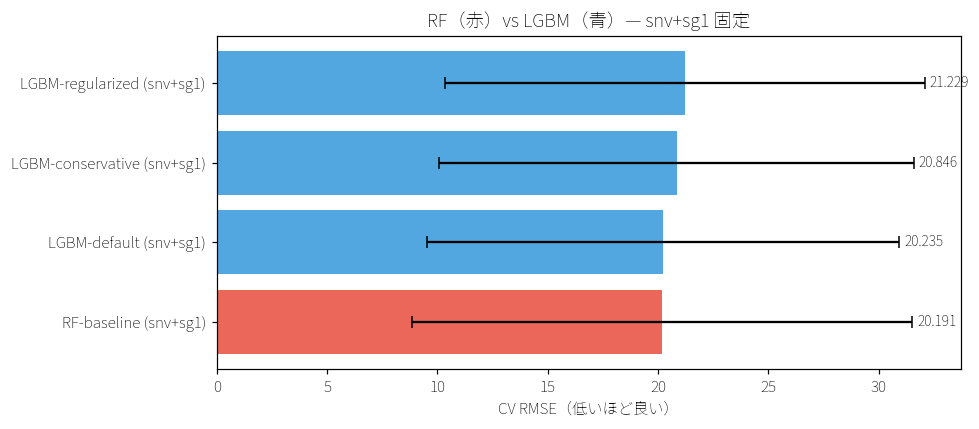


→ 最良 LGBM ハイパラ: LGBM-default


In [3]:
# 可視化
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if 'RF' in n else '#3498db' for n in df_1['name']]
ax.barh(df_1['name'], df_1['CV_RMSE'], xerr=df_1['CV_RMSE_std'],
        color=colors, alpha=0.85, capsize=4)
for i, row in df_1.iterrows():
    ax.text(row['CV_RMSE'] + row['CV_RMSE_std'] + 0.2, i,
            f"{row['CV_RMSE']:.3f}", va='center', fontsize=9)
ax.set_xlabel('CV RMSE（低いほど良い）')
ax.set_title('RF（赤）vs LGBM（青）— snv+sg1 固定')
plt.tight_layout()
plt.show()

# 最良 LGBM ハイパラを特定
lgbm_df = df_1[df_1['name'].str.startswith('LGBM')]
best_lgbm_name = lgbm_df.iloc[0]['name'].split(' ')[0]  # 'LGBM-xxx'
best_lgbm_model = LGBM_CONFIGS[best_lgbm_name]
print(f'\n→ 最良 LGBM ハイパラ: {best_lgbm_name}')

## 2. 最良 LGBM × 前処理比較

RF で有効だった前処理を LGBM でも検証する。

In [4]:
PREP_CANDIDATES = ['raw', 'snv+sg1', 'sg2', 'snv+sg2']

configs_2 = [
    {
        'name':         f'{best_lgbm_name} ({prep})',
        'preprocessor': build_preprocessor(prep),
        'selector':     NoSelection(),
        'model':        clone(best_lgbm_model),
    }
    for prep in PREP_CANDIDATES
]

df_2 = compare_pipelines(
    configs_2, X, y, groups, n_splits=N_SPLITS,
    save_dir='../results', filename='lgbm_step2_preprocessing.csv',
)
print_summary_table(df_2, f'実験2: {best_lgbm_name} × 前処理比較')

best_prep_lgbm = df_2.iloc[0]['name'].split('(')[1].rstrip(')')
print(f'\n→ LGBM 最良前処理: {best_prep_lgbm}')

  [LGBM-default (raw)] 

c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

RMSE=51.4776±49.6878  R²=-1.154  RPD=0.96(poor)  TrainRMSE=3.0422
  [LGBM-default (snv+sg1)] 

c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

RMSE=20.2351±10.7114  R²=0.820  RPD=2.45(fair)  TrainRMSE=0.3410
  [LGBM-default (sg2)] 

c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

RMSE=20.2153±10.3599  R²=0.820  RPD=2.45(fair)  TrainRMSE=0.2948
  [LGBM-default (snv+sg2)] 

c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

RMSE=18.5537±9.5939  R²=0.847  RPD=2.67(good)  TrainRMSE=0.3081
  → Saved: ..\results\lgbm_step2_preprocessing.csv

  実験2: LGBM-default × 前処理比較
                     name  CV_RMSE CV_RMSE_std   CV_R2   RPD Train_RMSE
0  LGBM-default (snv+sg2)  18.5537      9.5939   0.847  2.67     0.3081
1      LGBM-default (sg2)  20.2153     10.3599   0.820  2.45     0.2948
2  LGBM-default (snv+sg1)  20.2351     10.7114   0.820  2.45     0.3410
3      LGBM-default (raw)  51.4776     49.6878  -1.154  0.96     3.0422


→ LGBM 最良前処理: snv+sg2


c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 3. RF + LGBM アンサンブル

独立したモデルの予測を平均することで、単一モデルより安定した予測を狙う。

| アンサンブル | 内容 |
|-------------|------|
| 単純平均 | RF(snv+sg1) + LGBM(最良前処理) の予測を 50:50 で平均 |
| 加重平均 | CV RMSE の逆数で重み付け（より良いモデルに多く依存）|
| 3モデル平均 | RF(snv+sg1) + RF(raw) + LGBM(最良前処理) |

In [5]:
from src.utils import rmse as rmse_func

def oof_predict(prep_spec, model, X, y, groups, n_splits=5):
    """GroupKFold OOF 予測を返す。"""
    pred = np.zeros(len(y))
    for tr, va in GroupKFold(n_splits=n_splits).split(X, y, groups):
        pipe = Pipeline([
            ('prep',  clone(build_preprocessor(prep_spec))),
            ('sel',   NoSelection()),
            ('model', clone(model)),
        ])
        pipe.fit(X[tr], y[tr])
        pred[va] = pipe.predict(X[va])
    return pred

print('RF (snv+sg1) OOF 予測中...')
oof_rf = oof_predict('snv+sg1', RF_BASELINE, X, y, groups)

print(f'LGBM ({best_prep_lgbm}) OOF 予測中...')
oof_lgbm = oof_predict(best_prep_lgbm, best_lgbm_model, X, y, groups)

print('RF (raw) OOF 予測中...')
oof_rf_raw = oof_predict('raw', RF_BASELINE, X, y, groups)

# アンサンブル候補
ensembles = {
    'RF(snv+sg1)':              oof_rf,
    f'LGBM({best_prep_lgbm})':  oof_lgbm,
    'Ensemble 50:50':           (oof_rf + oof_lgbm) / 2,
    'Ensemble 加重':            None,  # 後で計算
    'Ensemble 3モデル':         (oof_rf + oof_lgbm + oof_rf_raw) / 3,
}

# 加重平均: CV RMSE の逆数で重み付け
rmse_rf   = rmse_func(y, oof_rf)
rmse_lgbm = rmse_func(y, oof_lgbm)
w_rf   = (1 / rmse_rf)   / (1 / rmse_rf + 1 / rmse_lgbm)
w_lgbm = (1 / rmse_lgbm) / (1 / rmse_rf + 1 / rmse_lgbm)
ensembles['Ensemble 加重'] = w_rf * oof_rf + w_lgbm * oof_lgbm

# 比較表
rows = []
for name, pred in ensembles.items():
    r = rmse_func(y, pred)
    rows.append({'name': name, 'OOF RMSE': r})

df_ens = pd.DataFrame(rows).sort_values('OOF RMSE').reset_index(drop=True)
print('\n=== アンサンブル比較 (OOF RMSE) ===')
print(df_ens.to_string(float_format='{:.4f}'.format))

best_ensemble_name = df_ens.iloc[0]['name']
best_oof = ensembles[best_ensemble_name]
print(f'\n→ 最良: {best_ensemble_name}  OOF RMSE={df_ens.iloc[0]["OOF RMSE"]:.4f}')

RF (snv+sg1) OOF 予測中...
LGBM (snv+sg2) OOF 予測中...


c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

RF (raw) OOF 予測中...

=== アンサンブル比較 (OOF RMSE) ===
             name  OOF RMSE
0     Ensemble 加重   20.8384
1   LGBM(snv+sg2)   20.8672
2  Ensemble 50:50   20.8886
3     RF(snv+sg1)   22.9636
4   Ensemble 3モデル   32.3684

→ 最良: Ensemble 加重  OOF RMSE=20.8384


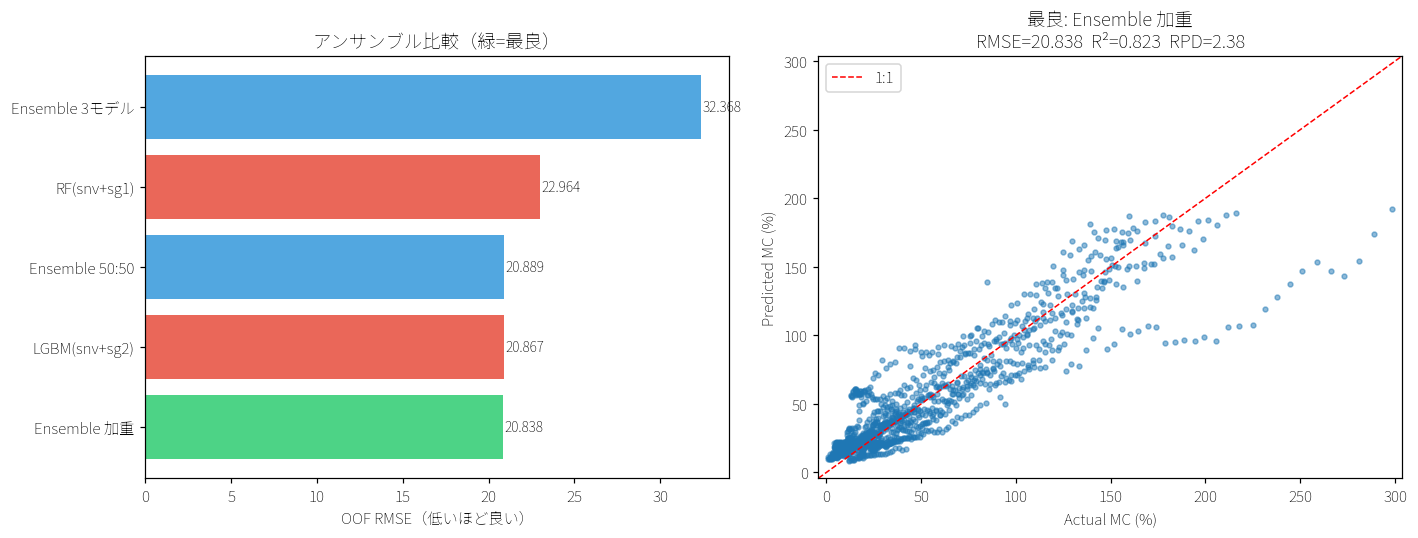

In [6]:
# アンサンブル可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 棒グラフ
ax = axes[0]
colors = ['#2ecc71' if i == 0 else '#3498db' if 'Ensemble' in df_ens.iloc[i]['name']
          else '#e74c3c' for i in range(len(df_ens))]
ax.barh(df_ens['name'], df_ens['OOF RMSE'], color=colors, alpha=0.85)
for i, row in df_ens.iterrows():
    ax.text(row['OOF RMSE'] + 0.1, i, f"{row['OOF RMSE']:.3f}", va='center', fontsize=9)
ax.set_xlabel('OOF RMSE（低いほど良い）')
ax.set_title('アンサンブル比較（緑=最良）')

# 最良アンサンブルの予測プロット
plot_predictions(y, best_oof, title=f'最良: {best_ensemble_name}', ax=axes[1])

plt.tight_layout()
plt.show()

## 4. 提出ファイル生成

全訓練データで再フィットし、テスト予測を生成する。  
単一モデルとアンサンブルの両方を出力する。

In [7]:
def fit_predict_test(prep_spec, model, X_tr, y_tr, X_te):
    """全訓練データでフィットしてテスト予測を返す。"""
    pipe = Pipeline([
        ('prep',  build_preprocessor(prep_spec)),
        ('sel',   NoSelection()),
        ('model', clone(model)),
    ])
    pipe.fit(X_tr, y_tr)
    return pipe.predict(X_te)

# 各モデルでテスト予測
print('RF (snv+sg1) テスト予測...')
test_rf = fit_predict_test('snv+sg1', RF_BASELINE, X, y, X_test)

print(f'LGBM ({best_prep_lgbm}) テスト予測...')
test_lgbm = fit_predict_test(best_prep_lgbm, best_lgbm_model, X, y, X_test)

print('RF (raw) テスト予測...')
test_rf_raw = fit_predict_test('raw', RF_BASELINE, X, y, X_test)

# 各アンサンブルのテスト予測
test_50_50   = (test_rf + test_lgbm) / 2
test_weighted = w_rf * test_rf + w_lgbm * test_lgbm
test_3model  = (test_rf + test_lgbm + test_rf_raw) / 3

# 提出ファイル保存
submissions = {
    f'lgbm_{best_lgbm_name}_{best_prep_lgbm}': test_lgbm,
    'ensemble_50_50':                            test_50_50,
    'ensemble_weighted':                         test_weighted,
    'ensemble_3model':                           test_3model,
}

for fname, pred in submissions.items():
    path = f'../submissions/{fname}.csv'
    make_submission(ds_test.meta, pred, path=path)

print(f'\nテスト予測範囲:')
for fname, pred in submissions.items():
    print(f'  {fname}: min={pred.min():.1f}  max={pred.max():.1f}  mean={pred.mean():.1f}')

RF (snv+sg1) テスト予測...
LGBM (snv+sg2) テスト予測...


c:\Users\rikky\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RF (raw) テスト予測...
Saved submission: ../submissions/lgbm_LGBM-default_snv+sg2.csv
Saved submission: ../submissions/ensemble_50_50.csv
Saved submission: ../submissions/ensemble_weighted.csv
Saved submission: ../submissions/ensemble_3model.csv

テスト予測範囲:
  lgbm_LGBM-default_snv+sg2: min=9.8  max=188.1  mean=47.6
  ensemble_50_50: min=10.7  max=170.7  mean=45.9
  ensemble_weighted: min=10.7  max=170.7  mean=46.0
  ensemble_3model: min=13.2  max=170.4  mean=49.0


In [8]:
# サマリー
print('=' * 60)
print('  実験07 サマリー')
print('=' * 60)
print(f'  最良 LGBM 設定 : {best_lgbm_name}')
print(f'  最良 LGBM 前処理: {best_prep_lgbm}')
print(f'  最良アンサンブル: {best_ensemble_name}')
print(f'  OOF RMSE: {df_ens.iloc[0]["OOF RMSE"]:.4f}')
print()
print('  提出候補:')
for fname in submissions:
    print(f'    submissions/{fname}.csv')
print('=' * 60)

  実験07 サマリー
  最良 LGBM 設定 : LGBM-default
  最良 LGBM 前処理: snv+sg2
  最良アンサンブル: Ensemble 加重
  OOF RMSE: 20.8384

  提出候補:
    submissions/lgbm_LGBM-default_snv+sg2.csv
    submissions/ensemble_50_50.csv
    submissions/ensemble_weighted.csv
    submissions/ensemble_3model.csv
